> **Acknowledgement**
>
> The initial workflow and several coding concepts used in this project were
> learned from the *Geographical Research Methods 1* course at Vrije Universiteit
> Brussel (VUB). The course practicals and accompanying code provided the
> foundation for the data preparation and classification workflow, which was
> subsequently adapted and extended for this project.
>
> For the original course materials and practical exercises, please refer to:
> - VUB Geographical Research Methods 1
> - [GRM1 practicals and code](https://github.com/rneyns/GRM1_public)

# **Reading and Processing Data**

In [66]:
# Loading required libraries
import numpy as np
import seaborn as sns
import pandas as pd
from osgeo import gdal
import math
import matplotlib.pyplot as plt

In [67]:
# loading the data

data = pd.read_csv(r'D:\GIS\GRM I\practical\2_Exercise_LandCoverClassification\Advanced\shapefiles\training_samples.csv')
data.head()

,id,class_name,b_1,b_2,b_3,b_4,b_5,b_6
0,1,Bare_Soil,660,971,1205,1979,3294,2851
1,1,Bare_Soil,693,1006,1261,2012,3271,2851
2,1,Bare_Soil,644,1040,1317,2045,3317,2916
3,1,Bare_Soil,693,1040,1317,2045,3339,2948
4,1,Bare_Soil,677,1074,1345,2112,3408,3046


In [3]:
# Controlling some information about the dataset

print(f"Number of samples: {len(data)}")
print("\nSamples per class:")
print(data["class_name"].value_counts())

print("\nDataset information:")
data.info()

Number of samples: 808

Samples per class:
class_name
Urban_Area    208
Bare_Soil     204
Vegetation    198
Water         198
Name: count, dtype: int64

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 808 entries, 0 to 807
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          808 non-null    int64
 1   class_name  808 non-null    str  
 2   b_1         808 non-null    int64
 3   b_2         808 non-null    int64
 4   b_3         808 non-null    int64
 5   b_4         808 non-null    int64
 6   b_5         808 non-null    int64
 7   b_6         808 non-null    int64
dtypes: int64(7), str(1)
memory usage: 50.6 KB


In [68]:
def get_band_columns(data):
    return [col for col in data.columns if col.startswith('b_')]

In [69]:
# Introducing the band columns for analysis and controlling some information

band_cols = get_band_columns(data)
data.groupby('class_name')[band_cols].describe()

b_1                                                           \
            count         mean          std    min     25%    50%      75%   
class_name                                                                   
Bare_Soil   204.0   793.823529   136.747253  514.0  689.00  775.5   866.00   
Urban_Area  208.0  1515.596154  2938.684319  375.0  788.25  964.0  1250.00   
Vegetation  198.0   385.752525    85.744304  249.0  326.00  371.0   426.00   
Water       198.0   299.904040   140.062444  116.0  211.25  255.0   338.25   

                       b_2               ...     b_5            b_6  \
                max  count         mean  ...     75%     max  count   
class_name                               ...                          
Bare_Soil    1218.0  204.0  1173.289216  ...  3609.0  4146.0  204.0   
Urban_Area  20000.0  208.0  1550.725962  ...  3433.0  5102.0  208.0   
Vegetation    703.0  198.0   597.297980  ...  2141.0  3419.0  198.0   
Water         803.0  198.0   411.393939  ...   290.0  1888.0  198.0   

                                                                               
                   mean         std     min      25%     50%      75%     max  
class_name                                                                     
Bare_Soil   2543.362745  514.418545  1445.0  2091.00  2646.0  2976.00  3839.0  
Urban_Area  2402.927885  713.941871   733.0  1929.00  2320.5  2787.00  4845.0  
Vegetation   967.090909  371.345409   442.0   702.00   926.0  1123.75  2712.0  
Water        191.924242  145.643886   -42.0    93.75   150.0   247.00  1155.0  

[4 rows x 48 columns]

In [6]:
# Controlling outliers

outliers = data[(data[band_cols] > 18000).any(axis=1)]
print(f"Number of observations above 18,000: {len(outliers)}")
outliers

Number of observations above 18,000: 5


,id,class_name,b_1,b_2,b_3,b_4,b_5,b_6
772,4,Urban_Area,20000,6192,6598,6782,4553,2319
773,4,Urban_Area,20000,6000,6275,6457,4462,2319
774,4,Urban_Area,20000,5548,5925,6099,4235,2319
775,4,Urban_Area,20000,6192,6544,6945,4485,2352
794,4,Urban_Area,20000,4795,5403,5701,4024,2381


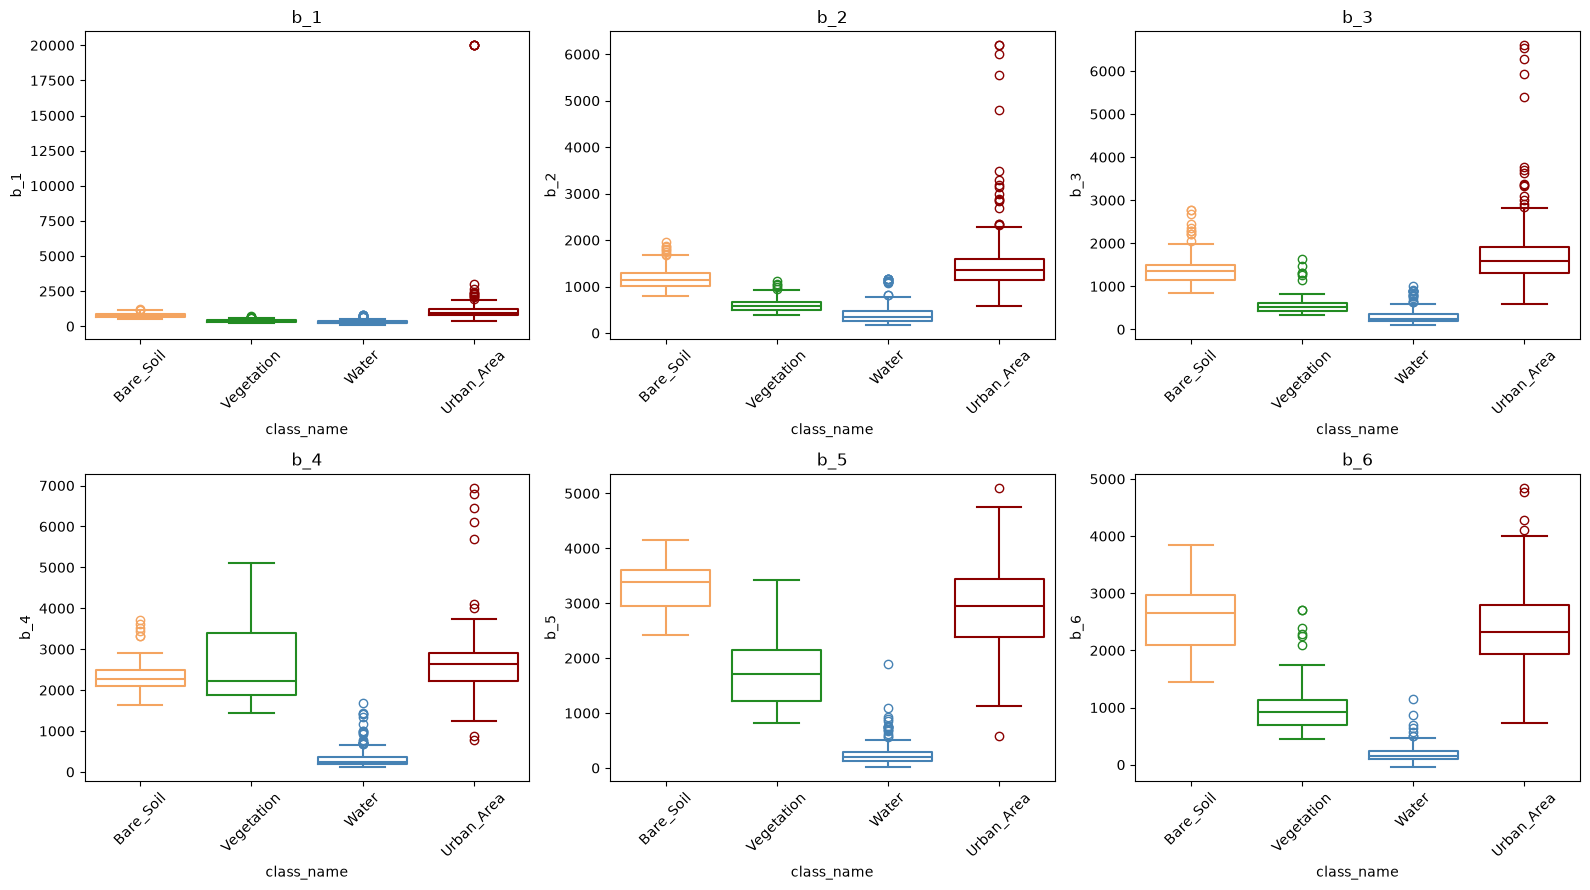

In [7]:
# Visualizing the distribution of band values for each class using boxplots

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
class_colors = {
    'Bare_Soil': 'sandybrown',
    'Vegetation': 'forestgreen',
    'Water': 'steelblue',
    'Urban_Area': 'darkred'
}

for ax, band in zip(axes.flat, band_cols):
    sns.boxplot(data=data, x='class_name', y=band, hue='class_name', palette=class_colors, fill=False, ax=ax, legend=False)
    ax.set_title(band)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

To get rid of outlier, you can follow method A or B. Don't run both together.

In [ ]:
# Method A
# Removing the outliers (Dropping the outliers caused by atmospheric correction)
"""
Blue band is strongly affected by atmospheric scattering, especially aerosols.
SWIR1 and SWIR2 bands are in wavelengths where atmospheric absorption effects can become important, 
particularly because of atmospheric gases/water vapour.
"""
data = data[data['b_1'] <= 18000] 
data = data[data['b_5'] <= 18000] 
data = data[data['b_6'] <= 18000]

In [ ]:
# Method B
# # Removing the outliers

data = data[data['b_1'] <= 25000]
data = data[data['b_2'] <= 25000]
data = data[data['b_3'] <= 25000]
data = data[data['b_4'] <= 25000]
data = data[data['b_5'] <= 25000]
data = data[data['b_6'] <= 25000]

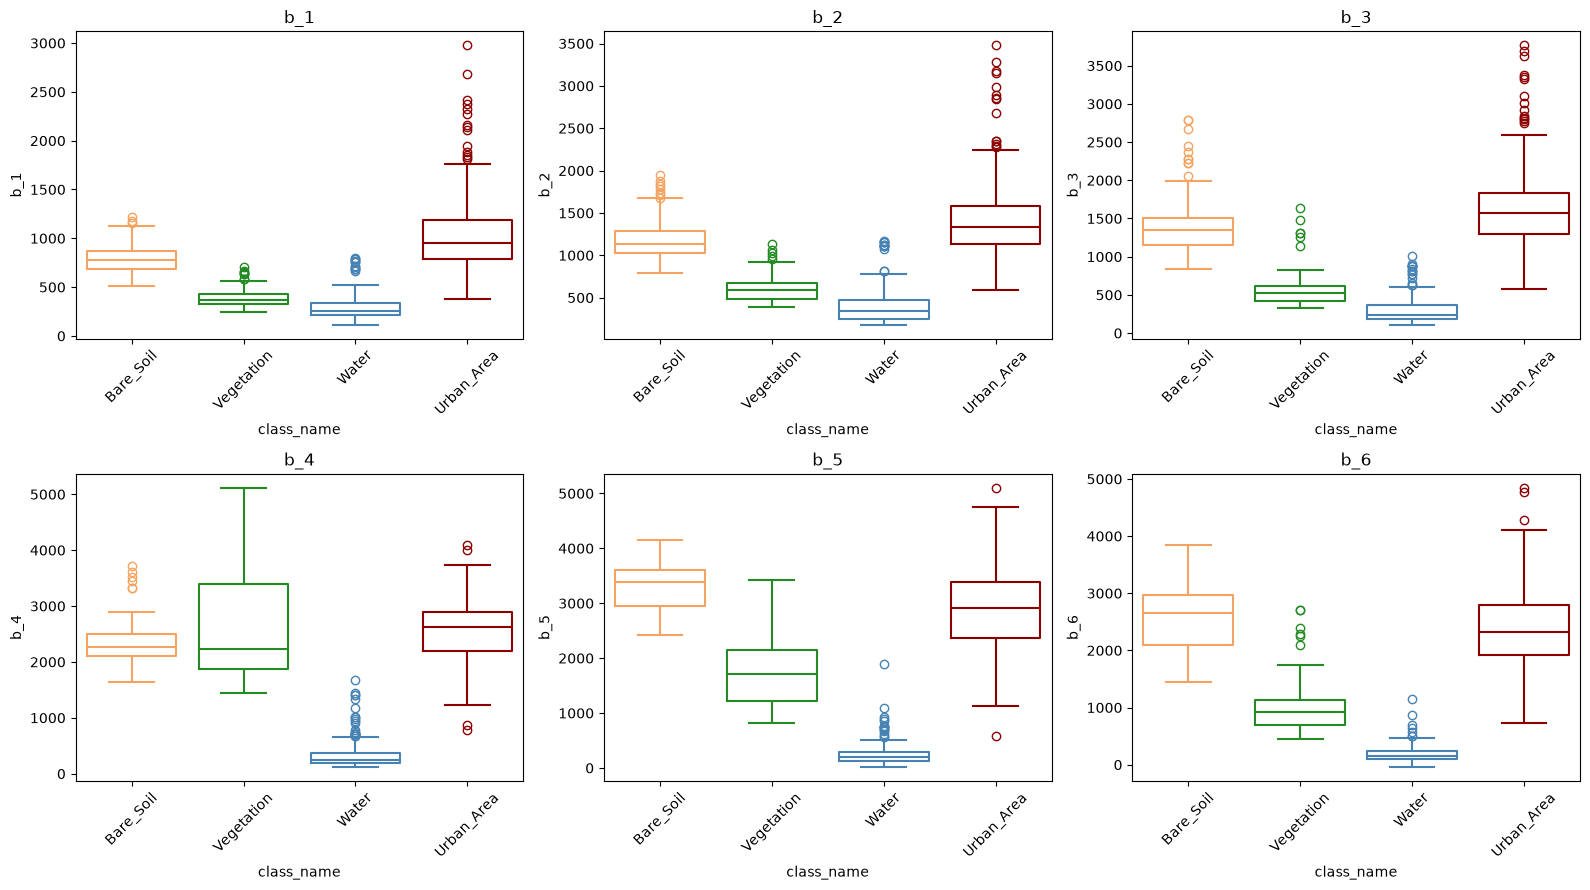

In [9]:
# Visualizing the distribution of band values for each class using boxplots after dropping outliers

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
class_colors = {
    'Bare_Soil': 'sandybrown',
    'Vegetation': 'forestgreen',
    'Water': 'steelblue',
    'Urban_Area': 'darkred'
}

for ax, band in zip(axes.flat, band_cols):
    sns.boxplot(data=data, x='class_name', y=band, hue='class_name', palette=class_colors, fill=False, ax=ax, legend=False)
    ax.set_title(band)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

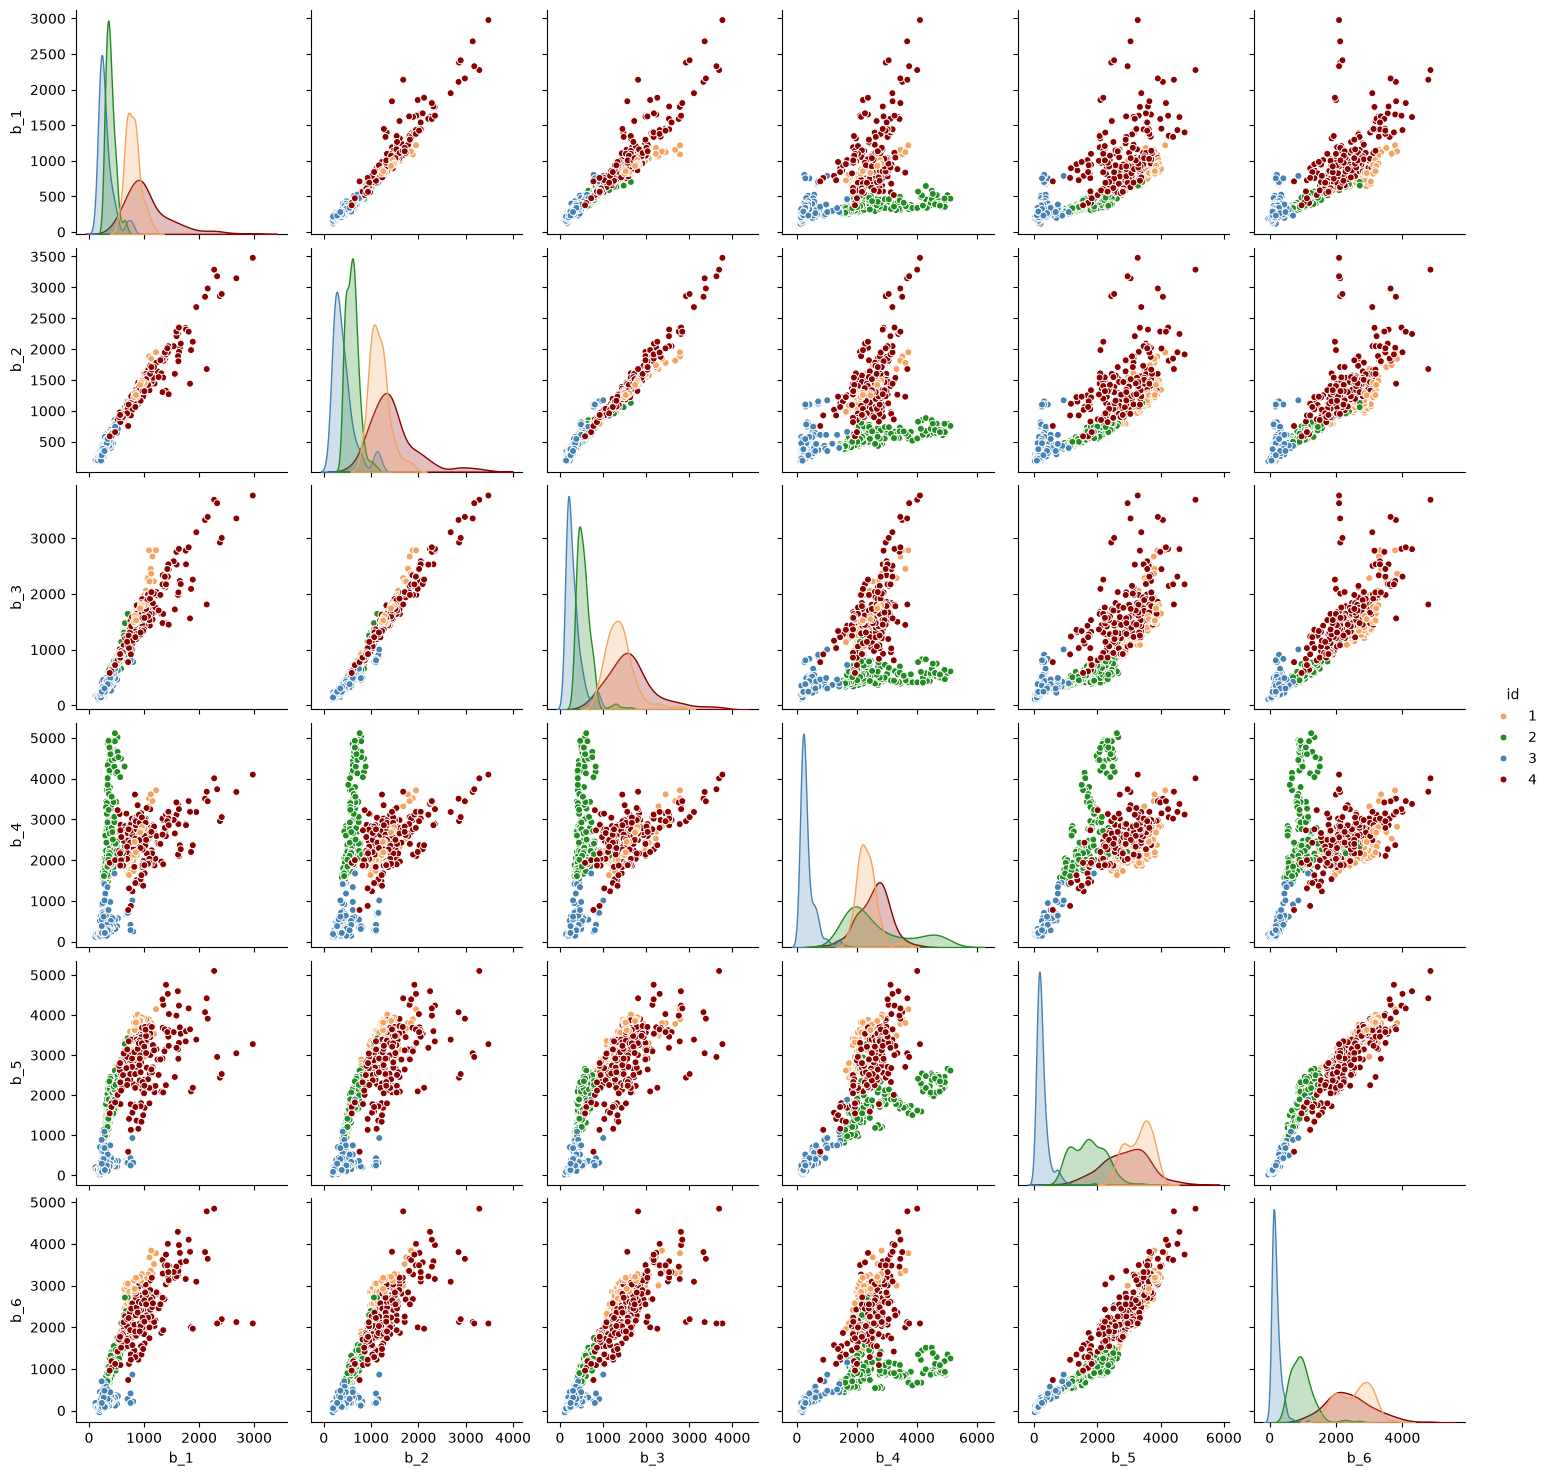

In [10]:
# Plotting the feature space distribution of the training samples
class_colors = {
    1: 'sandybrown',
    2: 'forestgreen',
    3: 'steelblue',
    4: 'darkred'
}

sns.pairplot(data=data, vars=band_cols, hue='id', palette=class_colors,
kind="scatter", plot_kws={'s': 25,'edgecolor': 'white','linewidth': 0.7})

In [11]:
def plot_spectral_signature(data):
    """
    A function to plot the spectral signature of each class based on the mean values of the bands.
    """
   
    # Plotting the spectral signature for each class
    plt.subplots(figsize=(8, 6))

    # Manipulating the dataframe for plotting
    data_pivot = data.T
    # number_bands = np.arange(1, len(data_pivot) + 1)
    # data_pivot.index = number_bands

    sns.lineplot(data=data_pivot) 
    
    plt.show()

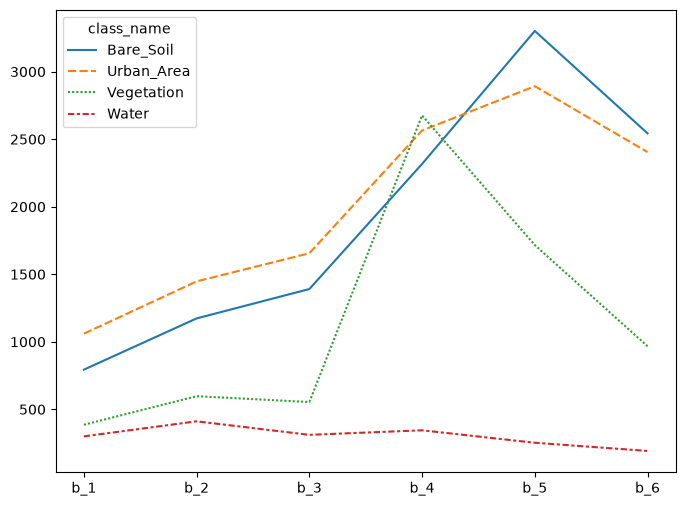

In [12]:
# Dropping unncessary columns 
data_vis = data.drop(['id'], axis=1)

# Taking the mean value for each value per class and plot it
data_mean = data_vis.groupby('class_name').mean()
plot_spectral_signature(data_mean)

In [25]:
# plotting all the spectaral signatures for each sample in the dataset, along with the mean spectral signature for each class.

def plot_spectral_signatures(data):
    
    # Finding the unique classes
    class_ids = sorted(data['id'].unique())
    number_classes = len(class_ids)
    
    # Determining number of rows and columns
    number_columns = math.ceil(math.sqrt(number_classes))
    number_rows = math.ceil(number_classes / number_columns)
    
    # Creating subplots
    fig, axes = plt.subplots(number_rows, number_columns, figsize=(4 * number_columns, 3 * number_rows))
    
    # Making axes iterable even if there is only one subplot
    axes = axes.flatten() if number_classes > 1 else [axes]
    
    # Plotting each class
    for ax, class_id in zip(axes, class_ids):
        
        # Selecting samples belonging to this class
        class_data = data[data['id'] == class_id]
        
        # Plotting every sample
        for _, sample in class_data.iterrows():
            ax.plot(band_cols, sample[band_cols], alpha=0.2, color=class_colors[class_id])
        
        # Calculating and plotting mean spectral signature
        mean_signature = class_data[band_cols].mean()
        
        ax.plot(band_cols, mean_signature, linewidth=2, color='black', label='Mean')
        
        # Formatting
        ax.set_title(f'Class {class_id}')
        ax.set_xlabel('Band')
        ax.set_ylabel('Reflectance')
        ax.legend()
        ax.grid(alpha=0.2)
    
    # Removing unused subplots
    for ax in axes[number_classes:]:
        ax.remove()
    
    plt.tight_layout()
    plt.show()

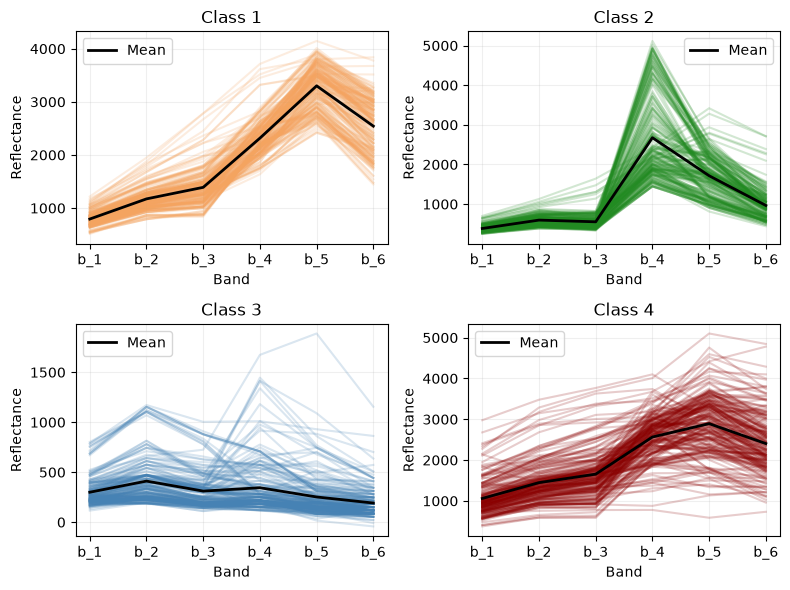

In [26]:
plot_spectral_signatures(data)

In [ ]:
# If you select Method A
# loading validation data and applying the same atmospheric correction as the training data (dropping the outliers)

val = pd.read_csv(r'D:\GIS\GRM I\practical\2_Exercise_LandCoverClassification\Advanced\shapefiles\validation_samples.csv')

val = val[val['b_1'] <= 18000] 
val = val[val['b_5'] <= 18000]
val = val[val['b_6'] <= 18000]
val.head()

,id,class_name,b_1,b_2,b_3,b_4,b_5,b_6
0,1,Bare_Soil,859,1315,1737,2376,3499,3176
1,1,Bare_Soil,859,1383,1794,2442,3544,3273
2,1,Bare_Soil,892,1383,1765,2508,3658,3273
3,1,Bare_Soil,892,1416,1877,2574,3636,3306
4,1,Bare_Soil,892,1349,1737,2475,3613,3208


In [ ]:
# If you select Method B
# loading validation data

val = pd.read_csv(r'D:\GIS\GRM I\practical\2_Exercise_LandCoverClassification\Advanced\shapefiles\validation_samples.csv')
val.head()

In [72]:
# splitting both training/validationsets in input and label sets
# The data is also transformed to a numpy array so it can be used in scikit-learn

train_x = data[band_cols].values
train_y = data['id'].values

val_x = val[band_cols].values
val_y = val['id'].values

# **Reading Raster File and Preparing ROI**

In [73]:
# Loading the GeoTIFF file (composite sattelite image)

raster_file = r'D:\GIS\GRM I\practical\2_Exercise_LandCoverClassification\Advanced\images\Colorado_Springs_2010.tif'
#driverTiff = gdal.GetDriverByName('GTiff')
raster = gdal.Open(raster_file)

In [74]:
# Converting the gdal raster file to a pandas dataframe

# Getting the number of bands
nbands = raster.RasterCount

# Creating an empty 2D array
data_raster = np.empty((raster.RasterXSize * raster.RasterYSize, nbands))

# Looping through the bands
for i in range(1, nbands+1): # Band numbering start from 1 in GDAL
    band = raster.GetRasterBand(i).ReadAsArray()
    data_raster[:, i-1] = band.flatten() # Python uses zero-based indexing

# Converting it into a dataframe and assigning the band names as column names
data_raster = pd.DataFrame(data_raster)
data_raster.columns = band_cols

data_raster.head()

,b_1,b_2,b_3,b_4,b_5,b_6
0,286.0,466.0,422.0,2080.0,1278.0,704.0
1,335.0,466.0,450.0,2080.0,1278.0,672.0
2,350.0,466.0,422.0,2047.0,1094.0,574.0
3,317.0,430.0,421.0,1948.0,1140.0,640.0
4,333.0,465.0,421.0,1948.0,1163.0,672.0


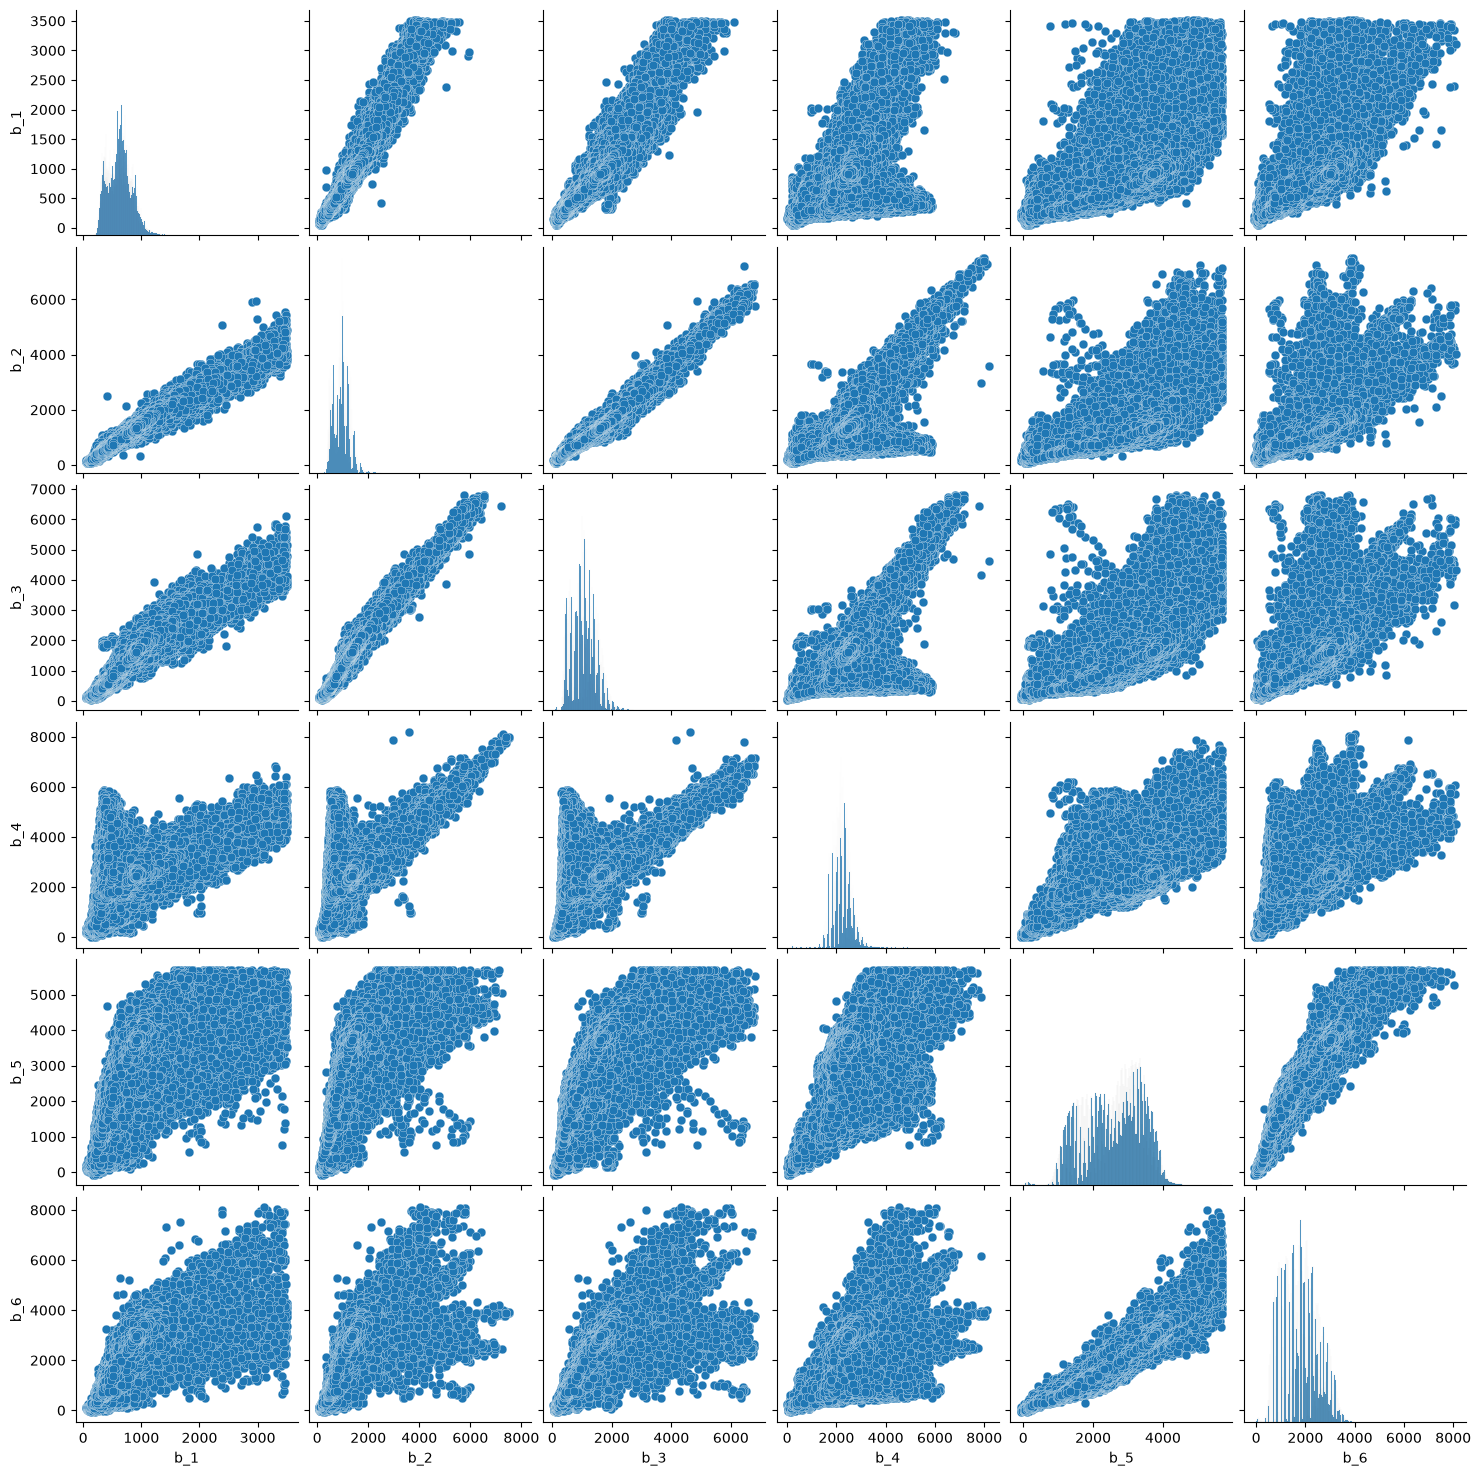

In [40]:
# Removing the outliers before visualisation

data_raster = data_raster[data_raster[ band_cols] <= 15000]
sns.pairplot(data=data_raster,
             kind="scatter", plot_kws=dict(s=40, edgecolor="white", linewidth=0.2))

# **Setting Up the Base Line Models**

In [75]:
# Importing required ML libraries for classification and evaluation

from sklearn.neighbors import NearestCentroid
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV

In [11]:
models = {
    'Nearest Centroid': NearestCentroid,
    'Maximum Likelihood Classifier': GaussianNB,
    'K-Nearest Neighbors': KNeighborsClassifier,
    'Multi-Layer Perceptron': MLPClassifier,
    'Decision Tree': DecisionTreeClassifier,
    'Random Forest': RandomForestClassifier
}

In [ ]:
# Function to train and validate the models

def model_classification(models, train_x, train_y, val_x, val_y):

    validation_result = []

    for model_name, model in models.items():
        # Training the model
        classifier = model()
        classifier.fit(train_x, train_y)

        # Estimating the accuracy of the model on the training and validation datasets
        predict_train = classifier.predict(train_x)
        accuracy_train = accuracy_score(train_y, predict_train)

        predict_val = classifier.predict(val_x)
        accuracy_val = accuracy_score(val_y, predict_val)

        # Estimating the confusion matrix and Cohen's Kappa score for the validation dataset
        cm = confusion_matrix(val_y, predict_val)
        Kappa = cohen_kappa_score(val_y, predict_val)

        validation_result.append({
            "model": model_name,
            "training_accuracy": accuracy_train,
            "validation_accuracy": accuracy_val,
            "kappa": Kappa,
            "confusion_matrix": cm,
            "classifier": classifier
        })

    return validation_result

In [18]:
output_folder = r"D:\GIS\GRM I\practical\2_Exercise_LandCoverClassification\Advanced\results"

In [19]:
# Running the classification models and saving the results to a CSV file

model_results = model_classification(models, train_x, train_y, val_x, val_y)
model_results_df = pd.DataFrame(model_results).sort_values(by="validation_accuracy", ascending=False)

output_path = f"{output_folder}\\model_results.csv"
model_results_df.to_csv(output_path, index=False)

In [ ]:

# Function to plot confusion matrices for each model

def plot_confusion_matrices(model_results, output_folder):

    for result in model_results:

        name = result["model"]
        cm = result["confusion_matrix"]

        fig, ax = plt.subplots(figsize=(7, 7))

        ConfusionMatrixDisplay(
            confusion_matrix=cm
        ).plot(
            cmap=plt.cm.Blues,
            values_format=".0f",
            ax=ax
        )

        ax.set_title(f"{name}", fontsize=14)

        # Save the figure
        output_path = f"{output_folder}\\confusion_matrix_{name}.png"
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

        plt.close(fig)


In [25]:
plot_confusion_matrices(model_results, output_folder)

In [44]:
# Function to classify the entire raster using the trained models and save the results as GeoTIFF files

def geoTIFF_Classified_Results(output_folder, model_results, data, raster):

    for result in model_results:

        model_name = result["model"]
        classifier = result["classifier"]

        # Classifying every pixel in the raster using the trained model
        classified_raster = classifier.predict(data.values).reshape((raster.RasterYSize, raster.RasterXSize))

        # Getting the GeoTIFF driver to save the classified raster as a GeoTIFF file
        driverTiff = gdal.GetDriverByName('GTiff') 

        # Creating a new GeoTIFF file to save the classified raster
        output_path = f"{output_folder}\\classified_{model_name}.tiff"
        clfds = driverTiff.Create(output_path, raster.RasterXSize, raster.RasterYSize, 1, gdal.GDT_Float32)

        # Copying the geographical information from the original raster to the classified raster and setting the NoData value
        clfds.SetGeoTransform(raster.GetGeoTransform())
        clfds.SetProjection(raster.GetProjection())
        clfds.GetRasterBand(1).SetNoDataValue(-9999.0)

        # Writting the classification results to the new GeoTIFF file
        clfds.GetRasterBand(1).WriteArray(classified_raster)

        # Visualizing the classified raster
        band = clfds.GetRasterBand(1)
        band.ReadAsArray()

In [45]:
geoTIFF_Classified_Results(output_folder, model_results, data_raster, raster)

# **Hyperparameters Tuning**

In [84]:
output_folder = r"D:\GIS\GRM I\practical\2_Exercise_LandCoverClassification\Advanced\results\tunned"

In [85]:
# Defining models and their parameters for Grid Search

model_params = {
    "Nearest Centroid": {
        "model": NearestCentroid(),
        "params": {
            'metric': ['euclidean', 'manhattan'],
            'shrink_threshold': [None, 0.1, 0.5, 1, 2, 5]
        },
    },

    "Maximum Likelihood Classifier": {
        "model": GaussianNB(),
        "params": {
            'var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
        },
    },

    "K-Nearest Neighbors": {
        "model": KNeighborsClassifier(),
        "params": {
            'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
            'weights': ['uniform', 'distance'],
            'p': [1, 2]
        },
    },

    "Multi-Layer Perceptron": {
        "model": MLPClassifier(max_iter=1000, random_state=42),
        "params": {
            'hidden_layer_sizes': [(6,), (12,), (18,), (24,), (12, 6)],
            'alpha': [0.0001, 0.001, 0.01],
            'learning_rate_init': [0.001, 0.01]
        },
    },

    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            'max_depth': [None, 3, 5, 7, 10, 15, 20],
            'min_samples_leaf': [1, 2, 5, 10, 20],
            'min_samples_split': [2, 5, 10],
            'criterion': ['gini', 'entropy']
        },
    },

    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {
            'n_estimators': [50, 100, 200, 300],
            'max_depth': [None, 5, 10, 15, 20],
            'min_samples_leaf': [1, 2, 5, 10],
            'max_features': ['sqrt', 'log2'],
            'bootstrap': [True, False]
        },
    },
}

In [86]:
# Tunning each model using GridSearchCV
def tune_models(model_params, train_x, train_y):

    grid_results = []

    for name, config in model_params.items():
        print(f"\nTuning model: {name}")

        # Retrieving the model and its corresponding hyperparameter grid
        model = config["model"]
        param_grid = config["params"]

        # Performing hyperparameter tuning using 5-fold cross-validation
        grid = GridSearchCV(
            model,
            param_grid,
            scoring="accuracy",
            cv=10,
            n_jobs=-1
        )

        # Fitting the pipeline to the training data
        grid.fit(train_x, train_y.ravel())

        # Store the tuning results
        grid_results.append({
            "model": name,
            "best_params": grid.best_params_,
            "cv_accuracy": grid.best_score_,
            "classifier": grid.best_estimator_
        })

    return grid_results

In [87]:
grid_results = tune_models(model_params, train_x, train_y)
grid_results_df = pd.DataFrame(grid_results).sort_values(by="cv_accuracy", ascending=False)

output_path = f"{output_folder}\\grid_search_results.csv"
grid_results_df.to_csv(output_path, index=False)


Tuning model: Nearest Centroid

Tuning model: Maximum Likelihood Classifier

Tuning model: K-Nearest Neighbors

Tuning model: Multi-Layer Perceptron

Tuning model: Decision Tree

Tuning model: Random Forest


In [88]:
# Function to validate the tunned models

def tunned_model_classification(grid_results, val_x, val_y):

    validation_results = []

    for result in grid_results:
        name = result["model"]
        model = result["classifier"]

        print(f"\nEvaluating model: {name}")

        # Predicting validation samples
        predictions = model.predict(val_x)

        # Accuracy assessment
        accuracy = accuracy_score(val_y, predictions)

        # Kappa assessment
        kappa = cohen_kappa_score(val_y, predictions)

        # Confusion matrix estimation
        cm = confusion_matrix(val_y, predictions)

        validation_results.append({
            "model": name,
            "validation_accuracy": accuracy,
            "kappa": kappa,
            "confusion_matrix": cm,
            "best_params": result["best_params"],
            "classifier": model
        })

    return validation_results



In [89]:
tunned_model_results = tunned_model_classification(grid_results, val_x, val_y)
tunned_model_results_df = pd.DataFrame(tunned_model_results).sort_values(by="validation_accuracy", ascending=False)

output_path = f"{output_folder}\\tunned_model_results.csv"
tunned_model_results_df.to_csv(output_path, index=False)


Evaluating model: Nearest Centroid

Evaluating model: Maximum Likelihood Classifier

Evaluating model: K-Nearest Neighbors

Evaluating model: Multi-Layer Perceptron

Evaluating model: Decision Tree

Evaluating model: Random Forest


In [90]:
plot_confusion_matrices(tunned_model_results, output_folder)

In [91]:
geoTIFF_Classified_Results(output_folder, tunned_model_results, data_raster, raster)